# PyTorch 与神经网络模型实践

## 1. PyTorch 基础

### 1.1 张量运算

**请使用 PyTorch 内置函数完成，避免显式循环。**

1. 创建一个形状为 (6, 5) 的随机整数张量 `A`，取值范围为 {0, 1, ..., 10}。打印出该张量；
2. 将 `A` 的每一行减去该行的均值（行中心化），得到张量 `A_centered`，使用广播实现。打印出该张量；
3. 打印出 `A_centered` 的行和向量以及列和向量。

In [1]:
import sys
!{sys.executable} -m pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [2]:
import torch

# 1. 创建一个形状为 (6, 5) 的随机整数张量 A，取值范围为 {0, 1, ..., 10}
A = torch.randint(0, 11, (6, 5)).float()  # 转为浮点型以便计算均值
print("张量 A:")
print(A)

# 2. 将 A 的每一行减去该行的均值（行中心化），使用广播实现
row_means = A.mean(dim=1, keepdim=True)  # 计算每行均值，保持维度以便广播
A_centered = A - row_means
print("\n行中心化后的张量 A_centered:")
print(A_centered)

# 3. 打印出 A_centered 的行和向量以及列和向量
row_sums = A_centered.sum(dim=1)
col_sums = A_centered.sum(dim=0)
print("\nA_centered 的行和向量:")
print(row_sums)
print("\nA_centered 的列和向量:")
print(col_sums)

张量 A:
tensor([[ 0.,  4.,  2., 10.,  8.],
        [ 7.,  9., 10.,  5.,  9.],
        [ 1.,  2.,  1.,  5.,  0.],
        [ 4.,  7.,  8.,  0.,  4.],
        [ 6.,  2.,  1.,  2.,  3.],
        [ 8.,  4.,  2.,  9.,  5.]])

行中心化后的张量 A_centered:
tensor([[-4.8000, -0.8000, -2.8000,  5.2000,  3.2000],
        [-1.0000,  1.0000,  2.0000, -3.0000,  1.0000],
        [-0.8000,  0.2000, -0.8000,  3.2000, -1.8000],
        [-0.6000,  2.4000,  3.4000, -4.6000, -0.6000],
        [ 3.2000, -0.8000, -1.8000, -0.8000,  0.2000],
        [ 2.4000, -1.6000, -3.6000,  3.4000, -0.6000]])

A_centered 的行和向量:
tensor([-9.5367e-07,  0.0000e+00,  2.3842e-07,  4.7684e-07,  2.3842e-07,
         4.7684e-07])

A_centered 的列和向量:
tensor([-1.6000,  0.4000, -3.6000,  3.4000,  1.4000])


以下每一步都需打印出操作的结果。

1. 创建一个形状为 (8, 8) 的随机正态分布张量 `X`（均值为 0.5，方差为2）；
2. 提取 `X` 中所有大于1.5的元素，构成一维张量；
3. 将 `X` 中绝对值小于0.5的元素替换为0，结果保存为张量 `X_masked`；
4. 取出 `X` 的第2行、第4列的元素；
5. 取出 `X` 的第3-6行、第2-5列构成的子矩阵。

In [3]:
import torch

# 1. 创建一个形状为 (8, 8) 的随机正态分布张量 X（均值为 0.5，方差为 2）
# torch.randn 生成标准正态分布 N(0,1)，需变换为 N(0.5, 2)
X = torch.randn(8, 8) * torch.sqrt(torch.tensor(2.0)) + 0.5
print("张量 X:")
print(X)

# 2. 提取 X 中所有大于 1.5 的元素，构成一维张量
X_gt_1_5 = X[X > 1.5]
print("\nX 中大于 1.5 的元素:")
print(X_gt_1_5)

# 3. 将 X 中绝对值小于 0.5 的元素替换为 0，结果保存为张量 X_masked
X_masked = X.clone()
X_masked[torch.abs(X_masked) < 0.5] = 0
print("\nX_masked (绝对值小于 0.5 的元素被替换为 0):")
print(X_masked)

# 4. 取出 X 的第 2 行、第 4 列的元素
# PyTorch 使用 0-based 索引，第 2 行对应索引 1，第 4 列对应索引 3
elem_2_4 = X[1, 3]
print(f"\nX 的第 2 行、第 4 列的元素: {elem_2_4:.4f}")

# 5. 取出 X 的第 3-6 行、第 2-5 列构成的子矩阵
# 第 3-6 行对应索引 2:6，第 2-5 列对应索引 1:5
sub_matrix = X[2:6, 1:5]
print("\nX 的第 3-6 行、第 2-5 列构成的子矩阵:")
print(sub_matrix)

张量 X:
tensor([[ 1.2836,  2.6229, -0.1399, -0.9507, -0.0092,  1.4080,  2.5600, -1.7241],
        [ 1.7446, -1.8097, -0.3107,  0.5391,  1.2264, -0.1691,  1.7140,  1.0719],
        [-1.5641,  1.2156,  2.0002,  1.6983,  0.3454,  0.5783,  0.8691,  1.1648],
        [-0.2677, -0.9186,  0.5812, -0.8483,  3.2054,  0.0846,  0.9723,  3.5552],
        [ 0.9104, -2.1140,  0.0374, -0.2693, -0.9293,  0.1842, -0.3385,  3.5182],
        [ 0.3644,  0.0694,  0.8761,  0.8164,  0.6567,  1.7586, -1.1978,  2.0839],
        [-0.1717,  1.7520,  1.2423, -0.3873, -2.3429,  0.8576,  3.3956,  3.8553],
        [-1.5110,  0.8444,  0.9397, -0.4975, -0.3907,  3.3047,  0.6925,  0.8535]])

X 中大于 1.5 的元素:
tensor([2.6229, 2.5600, 1.7446, 1.7140, 2.0002, 1.6983, 3.2054, 3.5552, 3.5182,
        1.7586, 2.0839, 1.7520, 3.3956, 3.8553, 3.3047])

X_masked (绝对值小于 0.5 的元素被替换为 0):
tensor([[ 1.2836,  2.6229,  0.0000, -0.9507,  0.0000,  1.4080,  2.5600, -1.7241],
        [ 1.7446, -1.8097,  0.0000,  0.5391,  1.2264,  0.0000,  1.714

### 1.2 常见函数与自动微分

多分类问题的数据通常包括数据阵 $X$ 和标签向量 $l$，其中标签为整数。在计算损失函数时，我们需要先将 $l$ 转换成多项分布的0-1数据，即所谓 One-hot 编码。运行并观察下面的代码。

In [4]:
import numpy as np
import torch
import torch.nn as nn

np.random.seed(123456)
torch.manual_seed(123456)

n = 200  # 样本量
p = 10   # 变量数
k = 4    # 类别数
x = torch.randn(n, p)
l = torch.tensor(np.random.choice(range(4), size=n, replace=True), dtype=int)
print(l[:20])

y = torch.nn.functional.one_hot(l)
print(y.shape)
print(y[:10])

tensor([1, 2, 2, 1, 0, 3, 3, 3, 3, 0, 3, 0, 0, 2, 2, 0, 3, 0, 3, 3])
torch.Size([200, 4])
tensor([[0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [1, 0, 0, 0]])


请创建矩阵 `W`，大小为 $k \times p$，用 N(0, 2) 填充其取值。

In [5]:
W = torch.randn(k, p) * torch.sqrt(torch.tensor(2.0))

# 检查 W 的形状，方便 debug
assert W.shape == (k, p), "W 形状有误"

接下来计算对 $Y$ 的概率预测值，其中每个 $Y_i$ 观测对应一个等长的概率向量 $p_i$，而 $p_i=\mathrm{Softmax}(Wx_i)$。首先计算 $Wx_i$，其中 $x_i$ 是第 $i$ 个观测。由于 $X$ 是把 $x_i$ 按行组合，因此矩阵形式表达为 $U=XW'$，其中 $U$ 的第 $i$ 行即为 $Wx_i$。

In [6]:
U = x @ W.T  # 或 torch.matmul(x, W.transpose(0, 1))

# 检查 U 的形状，方便 debug
assert U.shape == (n, k), "U 形状有误"

我们先测试一下 $\mathrm{Softmax}(Wx_{100})$ 的结果，观察其元素和是否为1。代码中的 `dim=0` 意思是对第一个下标方向计算 Softmax，由于 `U[99]` 是一个向量，因此第一个下标方向就是该向量本身。

In [7]:
torch.softmax(U[99], dim=0)

tensor([0.1481, 0.0201, 0.7261, 0.1056])

而为了对 $U$ 的每一行都计算 Softmax，我们可以直接对整个 `U` 矩阵用 `torch.softmax`，其中 `dim` 需指定为1，意思是对第二个下标方向求 Softmax，即对 $U$ 的每一行。原理类似于按坐标轴汇总。请完成该计算，得到矩阵 $P$，其中 $P$ 的第 $i$ 行即为 $p_i$。

In [8]:
P = torch.softmax(U, dim=1)

# 检查 P 的形状，方便 debug
assert P.shape == (n, k), "P 形状有误"

根据 `y` 和 `P` 两个矩阵，即可根据公式得到对数似然函数值。总结上述步骤，编写损失函数 `loss_fn_softmax(w, x, y)`，返回**负**对数似然值。

In [9]:
def loss_fn_softmax(w, x, y):
    u = x @ w.T
    p = torch.softmax(u, dim=1)
    loss = -torch.sum(y * torch.log(p + 1e-10)) / y.shape[0]
    return loss

Pytorch 中也提供了 CrossEntropyLoss 损失函数，参见[其文档](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)。其用法是先建立一个损失函数对象，然后将 $U$ 和 $l$ 作为参数传入（注意 $U$ 是经过 Softmax **之前**的矩阵，$l$ 是**原始**的标签）。请利用这种方法计算损失函数值，并与你自己的函数结果进行对比。

In [10]:
ce_softmax = nn.CrossEntropyLoss()
loss1 = ce_softmax(U, l)

loss2 = loss_fn_softmax(W, x, y)

print(loss1)
print(loss2)

tensor(4.4628)
tensor(4.4627)


【可以在此处添加必要的说明文字】

利用 PyTorch 的自动微分功能，计算上述损失函数在 $W=O$ 处的梯度，其中 $O$ 是一个元素全为0的矩阵。

In [11]:
O = torch.zeros(k, p, requires_grad=True)
loss_at_O = loss_fn_softmax(O, x, y)
loss_at_O.backward()
print(O.grad)

tensor([[-0.0198,  0.0474,  0.0067, -0.0427, -0.0012, -0.0092,  0.0167,  0.0030,
          0.0800, -0.0152],
        [ 0.0250, -0.0273, -0.0283,  0.0377,  0.0333, -0.0031,  0.0130,  0.0072,
         -0.0125,  0.0173],
        [-0.0236, -0.0355,  0.0060,  0.0342, -0.0175,  0.0324, -0.0054,  0.0260,
          0.0312, -0.0129],
        [ 0.0183,  0.0154,  0.0155, -0.0292, -0.0146, -0.0201, -0.0243, -0.0363,
         -0.0988,  0.0108]])


/home/steve3180586387/.local/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## 2. 前馈神经网络

### 2.1 线性模型

利用模块化编程（参考课件 `lec6-module.ipynb` 中的实现），在如下模拟数据上构建一个 Logistic 回归模型（包含截距项），并利用自动微分和优化器求解回归系数。要求使用 PyTorch 中的 `nn.Linear` 模块完成模型构建。

In [12]:
import numpy as np

def gen_data(n_obs=1000, radius=1.0, eye_oversample_ratio=0.0):
    factor = 1.5
    n_candidates = int(n_obs * factor)
    points = np.random.uniform(-radius, radius, size=(n_candidates, 2))

    r_sq = np.sum(points**2, axis=1)
    inside = (r_sq <= radius**2)
    points = points[inside]

    while len(points) < n_obs:
        extra = np.random.uniform(-radius, radius, size=(n_obs, 2))
        inside_extra = (np.sum(extra**2, axis=1) <= radius**2)
        extra = extra[inside_extra]
        points = np.vstack([points, extra])
    points = points[:n_obs]

    x1, x2 = points[:, 0], points[:, 1]
    half_r = radius / 2.0
    eye_r = radius / 5.0

    upper_semi = (x1 > 0) & ((x1**2 + (x2 - half_r)**2) <= half_r**2)
    lower_semi = (x1 < 0) & ((x1**2 + (x2 + half_r)**2) <= half_r**2)

    yang_eye = (x1**2 + (x2 - half_r)**2) <= eye_r**2
    yin_eye = (x1**2 + (x2 + half_r)**2) <= eye_r**2

    labels = np.full(len(points), -1, dtype=int)
    labels[upper_semi] = 0
    labels[yang_eye] = 1
    labels[lower_semi] = 1
    labels[yin_eye] = 0

    rest = (labels == -1)
    labels[rest & (x1 >= 0)] = 1
    labels[rest & (x1 < 0)] = 0

    if eye_oversample_ratio > 0:
        n_extra = int(n_obs * eye_oversample_ratio)

        def sample_disk(center, radius_disk, n):
            pts = np.random.uniform(-radius_disk, radius_disk, size=(int(n * 1.5), 2))
            inside_d = np.sum(pts**2, axis=1) <= radius_disk**2
            pts = pts[inside_d][:n]
            while len(pts) < n:
                extra_pts = np.random.uniform(-radius_disk, radius_disk, size=(n, 2))
                in_extra = np.sum(extra_pts**2, axis=1) <= radius_disk**2
                extra_pts = extra_pts[in_extra]
                pts = np.vstack([pts, extra_pts])[:n]
            return pts + np.array(center)

        extra_yang_pts = sample_disk(center=(0, half_r), radius_disk=eye_r, n=n_extra)
        extra_yang_labels = np.ones(n_extra, dtype=int)

        extra_yin_pts = sample_disk(center=(0, -half_r), radius_disk=eye_r, n=n_extra)
        extra_yin_labels = np.zeros(n_extra, dtype=int)

        points = np.vstack([points, extra_yang_pts, extra_yin_pts])
        labels = np.concatenate([labels, extra_yang_labels, extra_yin_labels])

    return points, labels

np.random.seed(123456)
x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)
print(x[:5])
print(y[:5])

[[-4.79047988  7.94473049]
 [-2.46500568 -3.27556511]
 [-0.97247059  6.80510167]
 [-7.53795711  0.86052404]
 [-2.5397555  -1.04006351]]
[0 1 0 0 1]


数据散点图：

/home/steve3180586387/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<Axes: xlabel='x1', ylabel='x2'>

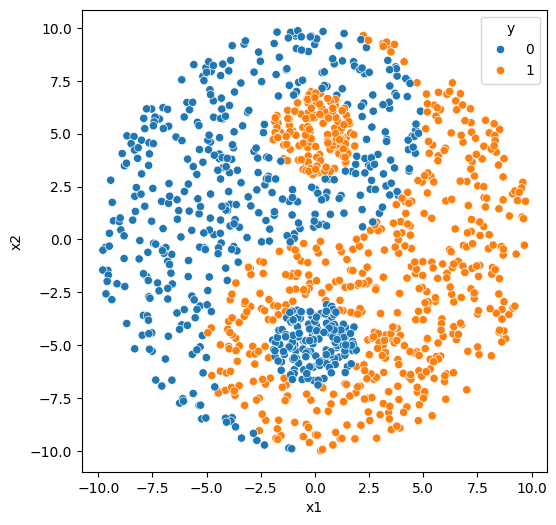

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dat = pd.DataFrame(x, columns=["x1", "x2"])
dat["y"] = y
plt.figure(figsize=(6, 6))
sns.scatterplot(data=dat, x="x1", y="x2", hue="y")

请在下方完成训练代码：

In [14]:
# 转换为 PyTorch 张量
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# 定义 Logistic 回归模型（nn.Linear 自动包含截距项）
model = nn.Linear(in_features=2, out_features=1)

# 损失函数和优化器
criterion = nn.BCEWithLogitsLoss()  # 结合 sigmoid + BCE，数值稳定
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# 训练
n_epochs = 1000
for epoch in range(n_epochs):
    logits = model(x_tensor)
    loss = criterion(logits, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

完成模型训练后，利用得到的模型对如下测试集数据进行预测（概率 >0.5 判为1，反之判为0），计算分类的正确率。

In [15]:
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)

In [16]:
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)

xtest_tensor = torch.tensor(xtest, dtype=torch.float32)
ytest_tensor = torch.tensor(ytest, dtype=torch.float32)

model.eval()
with torch.no_grad():
    logits_test = model(xtest_tensor)
    probs_test = torch.sigmoid(logits_test).squeeze()
    y_pred = (probs_test > 0.5).float()
    accuracy = (y_pred == ytest_tensor).float().mean()
    print(f"正确率: {accuracy.item():.4f}")

正确率: 0.6833


### 2.2 前馈神经网络

修改上面的线性模型，将其变为一个两层的前馈神经网络，隐藏神经元数量为32，使用 ReLU 激活函数。然后重新训练模型（可尝试使用不同的学习率和迭代次数），记录每次迭代的损失函数值并绘制损失函数值随迭代次数的曲线。最后对测试集进行预测，计算分类的正确率（目标是 >90%）。

Epoch [50/500], Loss: 0.4433
Epoch [100/500], Loss: 0.3491
Epoch [150/500], Loss: 0.2962
Epoch [200/500], Loss: 0.2544
Epoch [250/500], Loss: 0.2174
Epoch [300/500], Loss: 0.1892
Epoch [350/500], Loss: 0.1663
Epoch [400/500], Loss: 0.1487
Epoch [450/500], Loss: 0.1388
Epoch [500/500], Loss: 0.1315


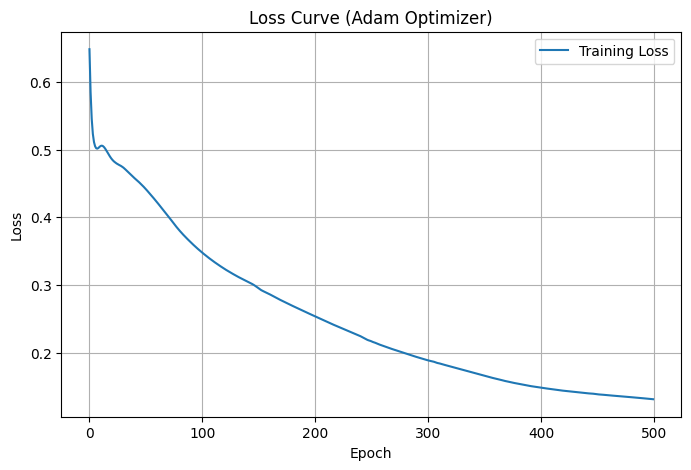

测试集正确率: 0.9167 (91.67%)


In [17]:
# 定义两层前馈神经网络
class TwoLayerNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super(TwoLayerNet, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

model_nn = TwoLayerNet(input_dim=2, hidden_dim=32, output_dim=1)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.01)

n_epochs = 500
loss_history = []

for epoch in range(n_epochs):
    logits = model_nn(x_tensor)
    loss = criterion(logits, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve (Adam Optimizer)')
plt.legend()
plt.grid(True)
plt.show()

# 测试
model_nn.eval()
with torch.no_grad():
    logits_test = model_nn(xtest_tensor)
    probs_test = torch.sigmoid(logits_test).squeeze()
    y_pred = (probs_test > 0.5).float()
    accuracy = (y_pred == ytest_tensor).float().mean()
    print(f"测试集正确率: {accuracy.item():.4f} ({accuracy.item()*100:.2f}%)")

### 2.3 Muon 优化器

请重新对上述前馈神经网络进行初始化和训练，但使用 Muon 优化器。**注意：Muon 只能对矩阵型参数进行优化，把向量型的参数传递给 Muon 会报错。**

请使用如下思路解决：构建两个优化器，Adam 和 Muon，将模型的参数分成两个列表，矩阵类的传递给 Muon，其他类的传递给 Adam，然后在训练循环中分别调用两个优化器的 `zero_grad()` 和 `step()` 函数。

请记录下这种方式下每次迭代的损失函数值，并与上一节中的曲线绘制在同一张图中进行对比。

Epoch [50/500], Loss: 0.4730
Epoch [100/500], Loss: 0.4053
Epoch [150/500], Loss: 0.3416
Epoch [200/500], Loss: 0.2951
Epoch [250/500], Loss: 0.2581
Epoch [300/500], Loss: 0.2230
Epoch [350/500], Loss: 0.1991
Epoch [400/500], Loss: 0.1827
Epoch [450/500], Loss: 0.1712
Epoch [500/500], Loss: 0.1612


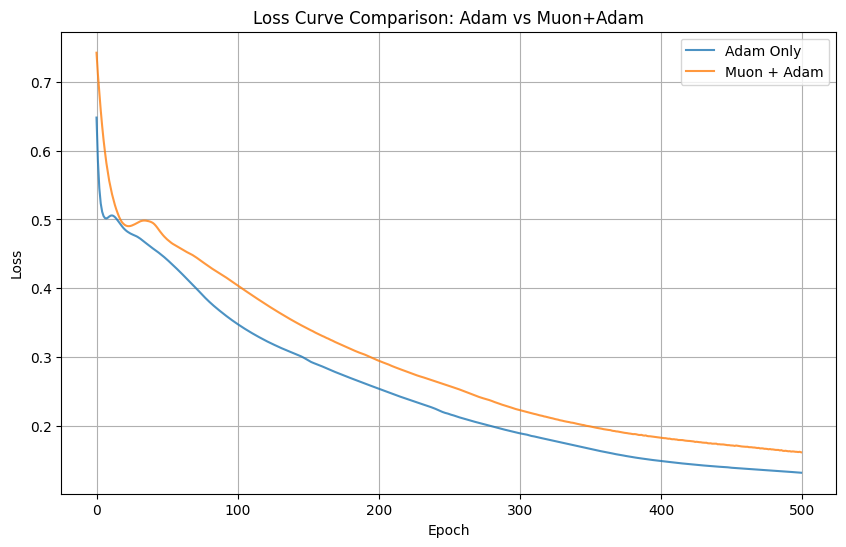

Muon 测试集正确率: 0.8958 (89.58%)


In [18]:
# 直接定义 Muon 优化器（无需安装，无需分布式）
import torch
from torch.optim.optimizer import Optimizer

@torch.no_grad()
def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    if G.size(0) > G.size(1):
        X = X.T
    X = X / (X.norm() + eps)
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, ns_steps=5, weight_decay=0.01):
        defaults = dict(lr=lr, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            weight_decay = group['weight_decay']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if 'momentum_buffer' not in state:
                    state['momentum_buffer'] = torch.zeros_like(g)
                buf = state['momentum_buffer']
                buf.mul_(momentum).add_(g)
                g = g.add_(buf, alpha=momentum) if group['nesterov'] else buf
                p.mul_(1 - lr * weight_decay)
                p.add_(zeropower_via_newtonschulz5(g, steps=group['ns_steps']), alpha=-lr)


# 重新初始化模型
model_muon = TwoLayerNet(input_dim=2, hidden_dim=32, output_dim=1)

# 参数分组：矩阵给 Muon，向量给 Adam
muon_params = []
adam_params = []

for p in model_muon.parameters():
    if p.ndim >= 2:
        muon_params.append(p)
    else:
        adam_params.append(p)

opt_muon = Muon(muon_params, lr=0.02, momentum=0.95)
opt_adam = torch.optim.Adam(adam_params, lr=0.01)

n_epochs_muon = 500
loss_history_muon = []

for epoch in range(n_epochs_muon):
    logits = model_muon(x_tensor)
    loss = criterion(logits, y_tensor)
    
    opt_muon.zero_grad()
    opt_adam.zero_grad()
    loss.backward()
    opt_muon.step()
    opt_adam.step()
    
    loss_history_muon.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs_muon}], Loss: {loss.item():.4f}')

# 对比绘图
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Adam Only', alpha=0.8)
plt.plot(loss_history_muon, label='Muon + Adam', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve Comparison: Adam vs Muon+Adam')
plt.legend()
plt.grid(True)
plt.show()

# Muon 模型测试
model_muon.eval()
with torch.no_grad():
    logits_test = model_muon(xtest_tensor)
    probs_test = torch.sigmoid(logits_test).squeeze()
    y_pred = (probs_test > 0.5).float()
    accuracy_muon = (y_pred == ytest_tensor).float().mean()
    print(f"Muon 测试集正确率: {accuracy_muon.item():.4f} ({accuracy_muon.item()*100:.2f}%)")

## 3. 预训练模型实战

请学习语音识别模型 Whisper 的使用方法（访问 [https://hf-mirror.com/openai/whisper-small](https://hf-mirror.com/openai/whisper-small) 或 [https://huggingface.co/openai/whisper-small](https://huggingface.co/openai/whisper-small)），完成以下任务：

1. 准备一段文字（内容任意，朗读出来大约10秒钟），填写在下方的文本框里。
2. 朗读这段文字，利用录音软件录制一段10秒左右的音频，保存为 `.wav` 格式。
3. 根据网站上的文档学习使用 Whisper 预训练模型，将预训练模型下载到本地，并识别你录制的音频，将其转为文字，打印出来。
4. 配备有 Nvidia GPU 的同学可以尝试参数量更大的 Whisper-Large 模型（访问 [https://hf-mirror.com/openai/whisper-large-v3](https://hf-mirror.com/openai/whisper-large-v3) 或 [https://huggingface.co/openai/whisper-large-v3](https://huggingface.co/openai/whisper-large-v3)），在 CUDA 模式下运行模型。

真实文字内容：【今天天气很好，我想去公园散步】

语音文件的文件名：【my_voice.wav】

In [19]:
import coverage.types
if not hasattr(coverage.types, 'Tracer'):
    class FakeTracer:
        pass
    coverage.types.Tracer = FakeTracer
if not hasattr(coverage.types, 'TShouldTraceFn'):
    coverage.types.TShouldTraceFn = object
if not hasattr(coverage.types, 'TTraceData'):
    coverage.types.TTraceData = object

import whisper
import soundfile as sf
import numpy as np
import torch

MODEL_SIZE = "small"
AUDIO_FILE = "my_voice.wav"
REAL_TEXT = "今天天气很好，我想去公园散步"

print("正在加载 Whisper 模型...")
model = whisper.load_model(MODEL_SIZE)
print("模型加载完成！")

print(f"\n正在识别音频: {AUDIO_FILE}")

# 用 soundfile 加载音频，绕过 librosa/numba
audio, sr = sf.read(AUDIO_FILE)
# 如果是多声道，取平均
if len(audio.shape) > 1:
    audio = audio.mean(axis=1)
# 重采样到 16kHz（简单线性插值）
if sr != 16000:
    import scipy.signal
    num_samples = int(len(audio) * 16000 / sr)
    audio = scipy.signal.resample(audio, num_samples)
audio = audio.astype(np.float32)
audio = torch.from_numpy(audio)

result = model.transcribe(audio, language="zh")

recognized_text = result["text"].strip()

print("\n" + "=" * 50)
print("【识别结果】")
print("=" * 50)
print(f"真实文字内容: {REAL_TEXT}")
print(f"识别文字内容: {recognized_text}")
print("=" * 50)

for segment in result["segments"]:
    start = segment["start"]
    end = segment["end"]
    text = segment["text"]
    print(f"[{start:.2f}s - {end:.2f}s] {text}")

正在加载 Whisper 模型...
模型加载完成！

正在识别音频: my_voice.wav


/home/steve3180586387/.local/lib/python3.12/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



【识别结果】
真实文字内容: 今天天气很好，我想去公园散步
识别文字内容: 今天天气很好,我想去公园散步。
[0.00s - 9.00s] 今天天气很好,我想去公园散步。
